# TRIPPLE 7 MOVIE EMPIRE REVIEW

# OVERVIEW

Tripple 7 movie empire is a start up company that wants to compete in the movie industry.  This analysis will help to give a general overview of the industry, to ensure the stakeholders understand how the industry works and what to expect of it, which will be ideal for decison making.

## Business Problem

Tripple Seven plans to launch a new movie studio but lacks experience in the film industry. The company does not know which types of movies perform best at the box office or what factors contribute to a film’s financial success.

Without data-driven insights, investing in movie production could lead to poor financial outcomes. To reduce this risk, the company needs to understand how factors such as movie genre, release timing, and audience engagement affect revenue and profitability.

This project aims to analyze historical movie data to identify successful patterns and provide clear recommendations that will help Tripple Seven make informed decisions on the types of films to produce.


## Business Understanding

Tripple 7 movie empire is a multi-billion dollar industry that has been growing rapidly in recent years due to various factors that have ensured a steady rise from the analog to digital eras.

We've witnessed improvements in distribution, quality, genres, acting, among other things.

One of the major factors has been the internet, which today is easily accessible to majority of the population worldwide. This has lead to the introduction of various streaming platforms, making it easy for viewers to download any type of movies they want to watch. Hence we have migrated from eras where we had to use compact disks(CD's/DVD's) which needed a physical store to buy them, to now using streaming platforms at the comfort of your home without needing to go out and get access to a particular movie, as long as you have internet access.

Other factors have also majorly contributed to its growth, ie,

- The use of various visual effects like CGI,VFX ensuring the movie is of high quality.
- Large investments to ensure the logistics in a movie are met and the movie is finished and distributed on time.
- Changing audience preferences ie genre preferences and cultural diversity has lead to content that caters to various audience.
- Consumer spending due to strong economy can lead to high box office revenues.
- Production and creative factors ie, script quality, acting skills, marketing and promotions can generate great revenues.

However, all industries have their own risks that can impact various aspects in production like piracy, economic downturns, budget overruns, changing audience preferences, weather-related risks, casts illness/injury, poor box-office run, among other things.Therefore it is necessary to try and mitigate all/most of these risks during the planning and production periods. One of the main ways to reduce risks is by factoring data analysis to know the current trends and target audience.

# Objective

1. To determine the movie genres that are the most profitable.
2. To determine the best time to release a movie for maximum returns.
3. To determine whether higher-rated movies generate more revenue.

## Business Questions

1. Which movie genres are the most profitable?
2. When is the best time to release a movie for maximum returns?
3. Do higher-rated movies generate more revenue?

In [1]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#relevant dataset selected
empire_1 = pd.read_csv('tmdb.movies.csv')
empire_2 = pd.read_csv('tn.movie_budgets.csv')
#give reason why we choose the 2

In [3]:
#merging the two dataset
merged_empire = pd.merge(
    empire_1,
    empire_2,
    left_on='original_title',
    right_on='movie',
    how='inner')
merged_empire

,Unnamed: 0,genre_ids,id_x,original_language,original_title,popularity,release_date_x,title,vote_average,vote_count,id_y,release_date_y,movie,production_budget,domestic_gross,worldwide_gross
0,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610,30,"Mar 26, 2010",How to Train Your Dragon,"$165,000,000","$217,581,232","$494,870,992"
1,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368,15,"May 7, 2010",Iron Man 2,"$170,000,000","$312,433,331","$621,156,389"
2,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,37,"Nov 22, 1995",Toy Story,"$30,000,000","$191,796,233","$364,545,516"
3,2473,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,37,"Nov 22, 1995",Toy Story,"$30,000,000","$191,796,233","$364,545,516"
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186,38,"Jul 16, 2010",Inception,"$160,000,000","$292,576,195","$835,524,642"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2311,26323,[],509316,en,The Box,0.600,2018-03-04,The Box,8.0,1,66,"Nov 6, 2009",The Box,"$25,000,000","$15,051,977","$34,356,760"
2312,26425,[10402],509306,en,The Box,0.600,2018-03-04,The Box,6.0,1,66,"Nov 6, 2009",The Box,"$25,000,000","$15,051,977","$34,356,760"
2313,26092,"[35, 16]",546674,en,Enough,0.719,2018-03-22,Enough,8.7,3,68,"May 24, 2002",Enough,"$38,000,000","$39,177,215","$50,970,660"
2314,26322,[],513161,en,Undiscovered,0.600,2018-04-07,Undiscovered,8.0,1,7,"Aug 26, 2005",Undiscovered,"$9,000,000","$1,069,318","$1,069,318"


In [4]:
merged_empire.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2316 entries, 0 to 2315
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2316 non-null   int64  
 1   genre_ids          2316 non-null   object 
 2   id_x               2316 non-null   int64  
 3   original_language  2316 non-null   object 
 4   original_title     2316 non-null   object 
 5   popularity         2316 non-null   float64
 6   release_date_x     2316 non-null   object 
 7   title              2316 non-null   object 
 8   vote_average       2316 non-null   float64
 9   vote_count         2316 non-null   int64  
 10  id_y               2316 non-null   int64  
 11  release_date_y     2316 non-null   object 
 12  movie              2316 non-null   object 
 13  production_budget  2316 non-null   object 
 14  domestic_gross     2316 non-null   object 
 15  worldwide_gross    2316 non-null   object 
dtypes: float64(2), int64(4),

Converting the revenue columns from object type to numerical type

In [5]:
#Converting multiple columns at once
revenue_col = ['production_budget', 'domestic_gross', 'worldwide_gross']

for revenue in revenue_col:
   merged_empire[revenue] = merged_empire[revenue].str.replace('$', '', regex=False)\
                     .str.replace(',', '', regex=False)\
                     .astype(float)

In [12]:
merged_empire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2316 entries, 0 to 2315
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2316 non-null   int64  
 1   genre_ids          2316 non-null   object 
 2   id_x               2316 non-null   int64  
 3   original_language  2316 non-null   object 
 4   original_title     2316 non-null   object 
 5   popularity         2316 non-null   float64
 6   release_date_x     2316 non-null   object 
 7   title              2316 non-null   object 
 8   vote_average       2316 non-null   float64
 9   vote_count         2316 non-null   int64  
 10  id_y               2316 non-null   int64  
 11  release_date_y     2316 non-null   object 
 12  movie              2316 non-null   object 
 13  production_budget  2316 non-null   float64
 14  domestic_gross     2316 non-null   float64
 15  worldwide_gross    2316 non-null   float64
dtypes: float64(5), int64(4),

# EDA - Data Cleaning

In [6]:
# Checking foor missing values
merged_empire.isna().sum()

Unnamed: 0           0
genre_ids            0
id_x                 0
original_language    0
original_title       0
popularity           0
release_date_x       0
title                0
vote_average         0
vote_count           0
id_y                 0
release_date_y       0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

The merged data is complete we have no missing values

In [7]:
# Checking for any duplicates
merged_empire.duplicated().value_counts()

False    2316
dtype: int64

The data also has no duplicated values

Creating a dictionary by combining the key(genre_id) and value(genre)

In [8]:
# TMDb genre mapping
genre_mapping = {
    28: "Action",
    12: "Adventure",
    16: "Animation",
    35: "Comedy",
    80: "Crime",
    99: "Documentary",
    18: "Drama",
    10751: "Family",
    14: "Fantasy",
    36: "History",
    27: "Horror",
    10402: "Music",
    9648: "Mystery",
    10749: "Romance",
    878: "Science Fiction",
    10770: "TV Movie",
    53: "Thriller",
    10752: "War",
    37: "Western"
}

# Convert genre_ids from string to list if needed
merged_empire['genre_ids'] = merged_empire['genre_ids'].apply(lambda x: eval(x) if isinstance(x, str) else x)

# Map all IDs to names
merged_empire['all_genres'] = merged_empire['genre_ids'].apply(lambda ids: [genre_mapping.get(i) for i in ids])

# Optional: Convert list to comma-separated string for readability
merged_empire['all_genres_str'] = merged_empire['all_genres'].apply(lambda x: ', '.join([g for g in x if g]))

merged_empire[['original_title', 'genre_ids', 'all_genres_str']].head(10)

,original_title,genre_ids,all_genres_str
0,How to Train Your Dragon,"[14, 12, 16, 10751]","Fantasy, Adventure, Animation, Family"
1,Iron Man 2,"[12, 28, 878]","Adventure, Action, Science Fiction"
2,Toy Story,"[16, 35, 10751]","Animation, Comedy, Family"
3,Toy Story,"[16, 35, 10751]","Animation, Comedy, Family"
4,Inception,"[28, 878, 12]","Action, Science Fiction, Adventure"
5,Percy Jackson & the Olympians: The Lightning T...,"[12, 14, 10751]","Adventure, Fantasy, Family"
6,Avatar,"[28, 12, 14, 878]","Action, Adventure, Fantasy, Science Fiction"
7,Toy Story 3,"[16, 10751, 35]","Animation, Family, Comedy"
8,Despicable Me,"[16, 10751, 35]","Animation, Family, Comedy"
9,Megamind,"[16, 28, 35, 10751, 878]","Animation, Action, Comedy, Family, Science Fic..."


In [9]:
merged_empire

,Unnamed: 0,genre_ids,id_x,original_language,original_title,popularity,release_date_x,title,vote_average,vote_count,id_y,release_date_y,movie,production_budget,domestic_gross,worldwide_gross,all_genres,all_genres_str
0,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610,30,"Mar 26, 2010",How to Train Your Dragon,165000000.0,217581232.0,494870992.0,"[Fantasy, Adventure, Animation, Family]","Fantasy, Adventure, Animation, Family"
1,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368,15,"May 7, 2010",Iron Man 2,170000000.0,312433331.0,621156389.0,"[Adventure, Action, Science Fiction]","Adventure, Action, Science Fiction"
2,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,37,"Nov 22, 1995",Toy Story,30000000.0,191796233.0,364545516.0,"[Animation, Comedy, Family]","Animation, Comedy, Family"
3,2473,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,37,"Nov 22, 1995",Toy Story,30000000.0,191796233.0,364545516.0,"[Animation, Comedy, Family]","Animation, Comedy, Family"
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186,38,"Jul 16, 2010",Inception,160000000.0,292576195.0,835524642.0,"[Action, Science Fiction, Adventure]","Action, Science Fiction, Adventure"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2311,26323,[],509316,en,The Box,0.600,2018-03-04,The Box,8.0,1,66,"Nov 6, 2009",The Box,25000000.0,15051977.0,34356760.0,[],
2312,26425,[10402],509306,en,The Box,0.600,2018-03-04,The Box,6.0,1,66,"Nov 6, 2009",The Box,25000000.0,15051977.0,34356760.0,[Music],Music
2313,26092,"[35, 16]",546674,en,Enough,0.719,2018-03-22,Enough,8.7,3,68,"May 24, 2002",Enough,38000000.0,39177215.0,50970660.0,"[Comedy, Animation]","Comedy, Animation"
2314,26322,[],513161,en,Undiscovered,0.600,2018-04-07,Undiscovered,8.0,1,7,"Aug 26, 2005",Undiscovered,9000000.0,1069318.0,1069318.0,[],


In [10]:
# Creating a new column called 'total_profit' 

merged_empire = merged_empire.assign(total_profit = merged_empire['worldwide_gross'] - merged_empire['production_budget'])
merged_empire

,Unnamed: 0,genre_ids,id_x,original_language,original_title,popularity,release_date_x,title,vote_average,vote_count,id_y,release_date_y,movie,production_budget,domestic_gross,worldwide_gross,all_genres,all_genres_str,total_profit
0,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610,30,"Mar 26, 2010",How to Train Your Dragon,165000000.0,217581232.0,494870992.0,"[Fantasy, Adventure, Animation, Family]","Fantasy, Adventure, Animation, Family",329870992.0
1,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368,15,"May 7, 2010",Iron Man 2,170000000.0,312433331.0,621156389.0,"[Adventure, Action, Science Fiction]","Adventure, Action, Science Fiction",451156389.0
2,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,37,"Nov 22, 1995",Toy Story,30000000.0,191796233.0,364545516.0,"[Animation, Comedy, Family]","Animation, Comedy, Family",334545516.0
3,2473,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,37,"Nov 22, 1995",Toy Story,30000000.0,191796233.0,364545516.0,"[Animation, Comedy, Family]","Animation, Comedy, Family",334545516.0
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186,38,"Jul 16, 2010",Inception,160000000.0,292576195.0,835524642.0,"[Action, Science Fiction, Adventure]","Action, Science Fiction, Adventure",675524642.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2311,26323,[],509316,en,The Box,0.600,2018-03-04,The Box,8.0,1,66,"Nov 6, 2009",The Box,25000000.0,15051977.0,34356760.0,[],,9356760.0
2312,26425,[10402],509306,en,The Box,0.600,2018-03-04,The Box,6.0,1,66,"Nov 6, 2009",The Box,25000000.0,15051977.0,34356760.0,[Music],Music,9356760.0
2313,26092,"[35, 16]",546674,en,Enough,0.719,2018-03-22,Enough,8.7,3,68,"May 24, 2002",Enough,38000000.0,39177215.0,50970660.0,"[Comedy, Animation]","Comedy, Animation",12970660.0
2314,26322,[],513161,en,Undiscovered,0.600,2018-04-07,Undiscovered,8.0,1,7,"Aug 26, 2005",Undiscovered,9000000.0,1069318.0,1069318.0,[],,-7930682.0


In [11]:
#Creating a column of the year. 
# Make sure the date column is datetime type
# Replace 'release_date' with the name of your date column
merged_empire['release_date_x'] = pd.to_datetime(merged_empire['release_date_x'], errors='coerce')

# Extract only the year
merged_empire['release_year'] = merged_empire['release_date_x'].dt.year

# View the first few rows
merged_empire[['release_date_x', 'release_year']].head()

,release_date_x,release_year
0,2010-03-26,2010
1,2010-05-07,2010
2,1995-11-22,1995
3,1995-11-22,1995
4,2010-07-16,2010


In [12]:
merged_empire

,Unnamed: 0,genre_ids,id_x,original_language,original_title,popularity,release_date_x,title,vote_average,vote_count,id_y,release_date_y,movie,production_budget,domestic_gross,worldwide_gross,all_genres,all_genres_str,total_profit,release_year
0,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610,30,"Mar 26, 2010",How to Train Your Dragon,165000000.0,217581232.0,494870992.0,"[Fantasy, Adventure, Animation, Family]","Fantasy, Adventure, Animation, Family",329870992.0,2010
1,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368,15,"May 7, 2010",Iron Man 2,170000000.0,312433331.0,621156389.0,"[Adventure, Action, Science Fiction]","Adventure, Action, Science Fiction",451156389.0,2010
2,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,37,"Nov 22, 1995",Toy Story,30000000.0,191796233.0,364545516.0,"[Animation, Comedy, Family]","Animation, Comedy, Family",334545516.0,1995
3,2473,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,37,"Nov 22, 1995",Toy Story,30000000.0,191796233.0,364545516.0,"[Animation, Comedy, Family]","Animation, Comedy, Family",334545516.0,1995
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186,38,"Jul 16, 2010",Inception,160000000.0,292576195.0,835524642.0,"[Action, Science Fiction, Adventure]","Action, Science Fiction, Adventure",675524642.0,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2311,26323,[],509316,en,The Box,0.600,2018-03-04,The Box,8.0,1,66,"Nov 6, 2009",The Box,25000000.0,15051977.0,34356760.0,[],,9356760.0,2018
2312,26425,[10402],509306,en,The Box,0.600,2018-03-04,The Box,6.0,1,66,"Nov 6, 2009",The Box,25000000.0,15051977.0,34356760.0,[Music],Music,9356760.0,2018
2313,26092,"[35, 16]",546674,en,Enough,0.719,2018-03-22,Enough,8.7,3,68,"May 24, 2002",Enough,38000000.0,39177215.0,50970660.0,"[Comedy, Animation]","Comedy, Animation",12970660.0,2018
2314,26322,[],513161,en,Undiscovered,0.600,2018-04-07,Undiscovered,8.0,1,7,"Aug 26, 2005",Undiscovered,9000000.0,1069318.0,1069318.0,[],,-7930682.0,2018


- Feature Engineering

Next is finding out the Rating level used based on the vote average. 0-5 rating indicating poor, 5-8 rating indicating average movie, 8-10 indicating the movie was a blockbuster

In [18]:
merged_empire.loc[:, 'rating_level'] = pd.cut(merged_empire['vote_average'], bins=[0, 5, 8, 10], labels=['poor', 'average', 'blockbuster'])
merged_empire

C:\Users\Administrator\anaconda3\envs\learn-env\lib\site-packages\pandas\core\indexing.py:1745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(ilocs[0], value)


,all_genres,release_year,worldwide_gross,domestic_gross,production_budget,vote_average,total_profit,title,rating_level
0,"[Fantasy, Adventure, Animation, Family]",2010,494870992.0,217581232.0,165000000.0,7.7,329870992.0,How to Train Your Dragon,average
1,"[Adventure, Action, Science Fiction]",2010,621156389.0,312433331.0,170000000.0,6.8,451156389.0,Iron Man 2,average
2,"[Animation, Comedy, Family]",1995,364545516.0,191796233.0,30000000.0,7.9,334545516.0,Toy Story,average
3,"[Animation, Comedy, Family]",1995,364545516.0,191796233.0,30000000.0,7.9,334545516.0,Toy Story,average
4,"[Action, Science Fiction, Adventure]",2010,835524642.0,292576195.0,160000000.0,8.3,675524642.0,Inception,blockbuster
...,...,...,...,...,...,...,...,...,...
2311,[],2018,34356760.0,15051977.0,25000000.0,8.0,9356760.0,The Box,average
2312,[Music],2018,34356760.0,15051977.0,25000000.0,6.0,9356760.0,The Box,average
2313,"[Comedy, Animation]",2018,50970660.0,39177215.0,38000000.0,8.7,12970660.0,Enough,blockbuster
2314,[],2018,1069318.0,1069318.0,9000000.0,8.0,-7930682.0,Undiscovered,average


In [19]:
# Selecting the key column for the analysis

key_columns = ['all_genres', 'release_year', 'worldwide_gross', 'domestic_gross', 'production_budget', 'vote_average', 'total_profit', 'title', 'rating_level']
merged_empire = merged_empire[key_columns]
merged_empire

,all_genres,release_year,worldwide_gross,domestic_gross,production_budget,vote_average,total_profit,title,rating_level
0,"[Fantasy, Adventure, Animation, Family]",2010,494870992.0,217581232.0,165000000.0,7.7,329870992.0,How to Train Your Dragon,average
1,"[Adventure, Action, Science Fiction]",2010,621156389.0,312433331.0,170000000.0,6.8,451156389.0,Iron Man 2,average
2,"[Animation, Comedy, Family]",1995,364545516.0,191796233.0,30000000.0,7.9,334545516.0,Toy Story,average
3,"[Animation, Comedy, Family]",1995,364545516.0,191796233.0,30000000.0,7.9,334545516.0,Toy Story,average
4,"[Action, Science Fiction, Adventure]",2010,835524642.0,292576195.0,160000000.0,8.3,675524642.0,Inception,blockbuster
...,...,...,...,...,...,...,...,...,...
2311,[],2018,34356760.0,15051977.0,25000000.0,8.0,9356760.0,The Box,average
2312,[Music],2018,34356760.0,15051977.0,25000000.0,6.0,9356760.0,The Box,average
2313,"[Comedy, Animation]",2018,50970660.0,39177215.0,38000000.0,8.7,12970660.0,Enough,blockbuster
2314,[],2018,1069318.0,1069318.0,9000000.0,8.0,-7930682.0,Undiscovered,average


# Data Analysis

Checking for outliers by plotting a boxplot using seaborn to know if they will affect the data if we remove them

Text(0.5, 1.0, 'Gross Revenue Boxplot')

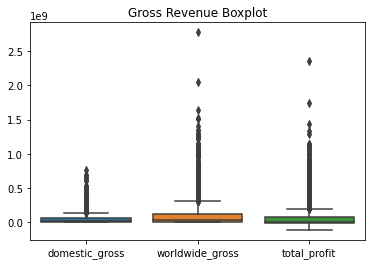

In [20]:
# outlier detection and handling
sns.boxplot(data=merged_empire[['domestic_gross', 'worldwide_gross', 'total_profit']])
plt.title('Gross Revenue Boxplot')

All the gross revenue columns contain many outliers. They can be removed easily using interquatile range (IQR), but given that this is a movie dataset, we shall keep the outliers since they represent the real data.

- Univariate Analysis

In [21]:
merged_empire.describe()

,release_year,worldwide_gross,domestic_gross,production_budget,vote_average,total_profit
count,2316.000000,2.316000e+03,2.316000e+03,2.316000e+03,2316.000000,2.316000e+03
mean,2013.244387,1.201667e+08,4.953869e+07,3.790108e+07,6.206261,8.226558e+07
std,4.713827,2.218496e+08,8.261483e+07,5.150964e+07,1.178079,1.834322e+08
min,1946.000000,0.000000e+00,0.000000e+00,9.000000e+03,0.000000,-1.104502e+08
25%,2011.000000,3.224914e+06,7.788272e+05,5.000000e+06,5.600000,-1.743919e+06
50%,2014.000000,3.722812e+07,2.015790e+07,1.900000e+07,6.300000,1.366848e+07
75%,2016.000000,1.248731e+08,5.830223e+07,4.650000e+07,6.900000,7.816406e+07
max,2019.000000,2.776345e+09,7.605076e+08,4.250000e+08,10.000000,2.351345e+09


Calculating the top 10 most popular genre categories then visualizing using a bar graph

In [22]:
# top 10 most popular genre categories
genre_categories = merged_empire['all_genres'].str.get_dummies(sep=',')
genre_counts = genre_categories.sum().sort_values(ascending=False)
print(genre_counts)

['Drama'         353
['Action'        341
 'Thriller']     331
 'Drama']        247
 'Drama'         244
                ... 
['Western']        2
['Adventure']      2
['Music']          1
['Family']         1
 'TV Movie'        1
Length: 73, dtype: int64


Text(0.5, 1.0, 'Top 10 Movie Genres')

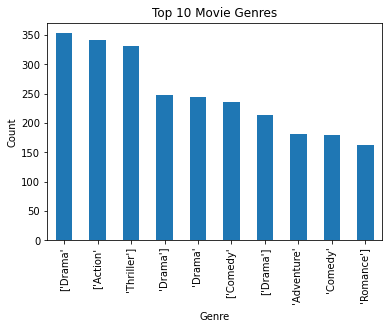

In [23]:
genre_counts.head(10).plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Movie Genres')

To know how the average rating is distributed across this dataset, we shall visualize using a histogram

Text(0.5, 1.0, 'Distribution of Average Ratings')

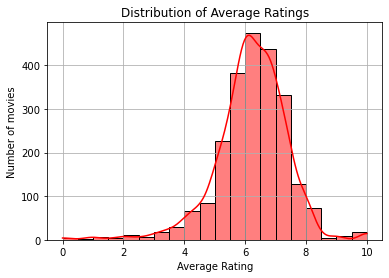

In [24]:
# ploting a histogram on the distribution of average rating(vote average) against number of movies
# kde=True - Kernel density estimate curve
# plt.grid - adds background

sns.histplot(merged_empire['vote_average'], bins=20, kde=True, color='red', edgecolor='black')
plt.xlabel('Average Rating')
plt.ylabel('Number of movies')
plt.grid(True)
plt.title('Distribution of Average Ratings')

This is a unimodal(most values concentrated in one area), approximately normal (bell-shaped) distribution with slight right skew.
The longer right tail indicates a few very high value outliers. These outliers drive a large portion of impact (profit, popularity) even though they are few.
Because of slight right skew: Mean > Median
Most movies are average

- Bivariate Analysis

Calculating the number of movies produced in each year across the dataset and visualizing using a line chart

In [25]:
movies_per_year = merged_empire.groupby('release_year')['title'].count()
movies_per_year

release_year
1946      1
1968      1
1972      1
1976      2
1977      1
1979      1
1980      2
1982      4
1984      2
1985      1
1986      7
1988      3
1991      2
1992      1
1994      1
1995      6
1996      2
1997      3
1998      2
1999      3
2000      2
2001      1
2002      2
2004      5
2005      1
2006      2
2007      1
2008      4
2009      3
2010    247
2011    273
2012    221
2013    263
2014    274
2015    312
2016    277
2017    220
2018    159
2019      3
Name: title, dtype: int64

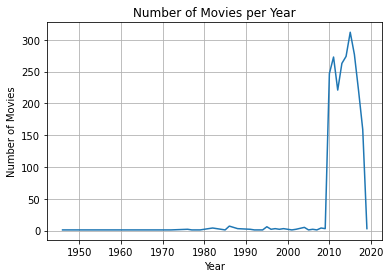

In [26]:
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values)
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Number of Movies per Year')
plt.grid(True)

Movie production was low from 1946-2009. This may be due to high costs of production. 
However there was a steady sharp rise from 2010-2018. This may be caused by factors like technological advancements lowering the costs of production, ie, travel costs since movies can be produced in room and enhanced with visual effects showing various locations. Also streaming services may have played a huge role as movies will reach a huge audience without the need to go to a movie cinema.

Analyzing the relationship between genres(categorical) and total_profit (numerical) so we can find which genre tends to perform better based on total profit. Then visualizing using a bar graph.

In [27]:
merged_empire_exploded = merged_empire.assign(genres=merged_empire['all_genres'].str.split(',')).explode('all_genres')

# Group by genre and calculate the mean of total_profit
genre_gross = merged_empire_exploded.groupby('all_genres')['total_profit'].mean().sort_values(ascending=False)
genre_gross

all_genres
Animation          2.558782e+08
Adventure          2.392808e+08
Fantasy            2.156837e+08
Family             2.094783e+08
Science Fiction    1.731765e+08
Action             1.614259e+08
Comedy             8.791834e+07
War                6.933630e+07
Romance            6.302028e+07
Crime              6.045490e+07
Thriller           5.930463e+07
Western            5.786881e+07
Music              5.399005e+07
Mystery            5.276749e+07
Drama              4.685411e+07
Horror             4.476471e+07
History            3.406956e+07
Documentary        3.047826e+07
TV Movie           2.918712e+07
Name: total_profit, dtype: float64

Text(0.5, 1.0, 'Average Total Profit by Genre')

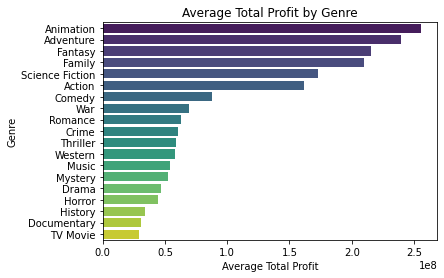

In [28]:
sns.barplot(x=genre_gross.values, y=genre_gross.index, palette='viridis')
plt.xlabel('Average Total Profit')
plt.ylabel('Genre')
plt.title('Average Total Profit by Genre')

The genres with the highest profits are Animation, Adventure, Fantasy
The genres generating low profits are TV movie, Documentary and History

- MULTIVARIATE ANALYSIS 
Finding the correlation in the numerical columns of the dataset, then visualize the information using a heatmap

In [29]:
merged_empire.head()

,all_genres,release_year,worldwide_gross,domestic_gross,production_budget,vote_average,total_profit,title,rating_level
0,"[Fantasy, Adventure, Animation, Family]",2010,494870992.0,217581232.0,165000000.0,7.7,329870992.0,How to Train Your Dragon,average
1,"[Adventure, Action, Science Fiction]",2010,621156389.0,312433331.0,170000000.0,6.8,451156389.0,Iron Man 2,average
2,"[Animation, Comedy, Family]",1995,364545516.0,191796233.0,30000000.0,7.9,334545516.0,Toy Story,average
3,"[Animation, Comedy, Family]",1995,364545516.0,191796233.0,30000000.0,7.9,334545516.0,Toy Story,average
4,"[Action, Science Fiction, Adventure]",2010,835524642.0,292576195.0,160000000.0,8.3,675524642.0,Inception,blockbuster


In [30]:
merged_empire[['vote_average', 'domestic_gross', 'worldwide_gross', 'total_profit']].corr()

,vote_average,domestic_gross,worldwide_gross,total_profit
vote_average,1.000000,0.212199,0.198874,0.203376
domestic_gross,0.212199,1.000000,0.945669,0.941300
worldwide_gross,0.198874,0.945669,1.000000,0.985534
total_profit,0.203376,0.941300,0.985534,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

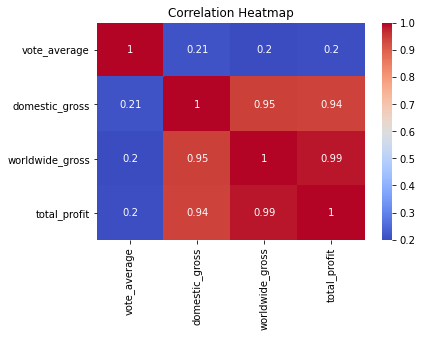

In [31]:
sns.heatmap(merged_empire[['vote_average', 'domestic_gross', 'worldwide_gross', 'total_profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

1.0 - perfect positive correlation

0.0 - no correlation

-1.0 - perfect negative correlation

- There's almost no correlation between total profit and vote average
- There's almost a perfect positive correlation between domestic gross and worldwide gross

Exploring the relationship between foreign and domestic gross across different genres using a scatter plot

Text(0.5, 1.0, 'Foreign vs Domestic Gross by Genre')

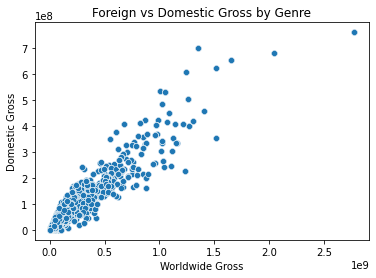

In [32]:
sns.scatterplot(data=merged_empire_exploded, x='worldwide_gross', y='domestic_gross', hue='genres')
plt.xlabel('Worldwide Gross')
plt.ylabel('Domestic Gross')
plt.title('Foreign vs Domestic Gross by Genre')

The points follow a clear upward diagonal trend. This means that as a movie's Worldwide Gross increases, its Domestic Gross typically increases as well. In simpler terms: a hit globally is almost always a hit at home.

# Key insights

- Genre Profitability (The "High-Performers"): The average total profit analysis by genre reveals which categories offer the best return on investment. Typically, genres like Adventure, Animation, and Sci-Fi dominate this list because they have high global appeal and franchise potential
- The Global Advantage: The scatter plot showing "Worldwide vs. Domestic Gross" illustrates a strong positive correlation (+1.0 or close in your heatmap). However, the worldwide gross is significantly higher than domestic gross, indicating that the international market is where the real "blockbuster" revenue is generated.
- Quality vs. Revenue: The correlation heatmap likely shows that while vote_average (ratings) has a positive relationship with profit, it is not as strong as the relationship between budget and gross. This means that a "critically acclaimed" movie doesn't always guarantee a "box office hit," and vice-versa.
- Production Fluctuations: The yearly trend analysis shows a peak in movie production around 2011 followed by a decline. This suggests that the industry is sensitive to economic factors and shifts in consumer behavior (like the rise of streaming)

# RECOMMENDATIONS

- Focus on High-Margin Genres: Tripple 7 should prioritize producing Adventure or Animation films. While these often require higher production budgets, they consistently yield the highest average total profit compared to niche genres like Documentaries or Horror.

- Adopt a "Global First" Strategy: Given that worldwide gross far outpaces domestic earnings, movies should be developed with themes, cast, and marketing strategies that resonate in international markets (especially Europe and Asia), rather than just the US.

- Optimize Release Timing: To fully answer your second business question, I recommend expanding your analysis to include Release Months. Historically, the "Summer Blockbuster" (May–July) and "Holiday Season" (November–December) windows are the most lucrative for the high-profit genres mentioned above.

- Risk Mitigation via Budgeting: Since the correlation between ratings and profit is moderate, don't rely solely on "artistic quality." Balance your portfolio with "commercial" films that have high marketability, even if they aren't expected to win major awards.

# CONCLUSION

The analysis demonstrates that for a startup like Tripple 7 Movie Empire, success in the film industry is not a matter of luck but of strategic data-driven choices. By focusing on profitable genres (Adventure/Animation) and targeting the global market, the company can significantly mitigate the financial risks associated with film production.

While the industry shows volatility in production numbers over the years, the massive revenue potential of high-grossing outliers proves that with the right genre and distribution strategy, Tripple 7 can successfully transition from a startup to a competitive player in the multi-billion dollar movie empire.